# K-Means Clustering



## Theory

K-means clustering partitions data into \(k\) groups by minimizing the sum of
squared distances between points and their assigned centroid. The basic
descent algorithm alternates between assigning points to the nearest centroid
and recomputing centroids as the mean of their assigned points.

Because the algorithm relies on Euclidean distance, it is highly sensitive to
the scale of the features – hence the importance of using the same scaler that
is applied to our supervised models. When \(k=2\) we can attempt to map each
cluster to a direction label (Up/Down) by looking at the majority class within
each cluster on the training set. This mapping is arbitrary and must be learned
from the data; cluster ids themselves have no meaning.

We will code a simple scratch version and then compare to
`sklearn.cluster.KMeans`. We will also discuss how to choose \(k\) and show a
frontier of accuracies for different values.

## 1. Imports, Setup & Shared Utilities

In [1]:
import os, json, pickle, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import (confusion_matrix, roc_auc_score, roc_curve, accuracy_score)
from sklearn.cluster import KMeans

BASE_DIR = r"D:\Repo\cryptoflow"

print("os.chdir =", os.getcwd())
print("BASE_DIR =", BASE_DIR)
TRAIN_FILE    = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_train.csv')
TEST_FILE     = os.path.join(BASE_DIR, 'data', 'final_training_data_classification_test.csv')
FEATURES_FILE = os.path.join(BASE_DIR, 'data', 'selected_features_classification.json')
SCALER_FILE   = os.path.join(BASE_DIR, 'models', 'scaler_classification.pkl')
MODELS_DIR    = os.path.join(BASE_DIR, 'models')
RESULTS_DIR   = os.path.join(BASE_DIR, 'results')
PLOTS_DIR     = os.path.join(BASE_DIR, 'plots')
RESULTS_CSV   = os.path.join(RESULTS_DIR, 'classification_results.csv')

os.makedirs(RESULTS_DIR, exist_ok=True)
os.makedirs(MODELS_DIR, exist_ok=True)
os.makedirs(PLOTS_DIR, exist_ok=True)

# utilities

def compute_metrics(model_name, y_true, y_pred, y_prob=None):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    accuracy    = (tp + tn) / (tp + tn + fp + fn)
    precision   = tp / (tp + fp) if (tp + fp) > 0 else 0.0
    sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0.0
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0
    f1          = 2*precision*sensitivity/(precision+sensitivity) if (precision+sensitivity) > 0 else 0.0
    auc         = roc_auc_score(y_true, y_prob) if y_prob is not None else float('nan')
    print(f"\n{'='*55}\n  {model_name}\n{'='*55}")
    print(f"  Confusion Matrix : TN={tn}  FP={fp}  FN={fn}  TP={tp}")
    print(f"  Accuracy         : {accuracy:.4f}")
    print(f"  Precision        : {precision:.4f}")
    print(f"  Sensitivity      : {sensitivity:.4f}")
    print(f"  Specificity(TNR) : {specificity:.4f}")
    print(f"  F1-Score         : {f1:.4f}")
    print(f"  ROC-AUC          : {auc:.4f}")
    print(f"{'='*55}")
    return {'model': model_name, 'accuracy': round(accuracy,4), 'precision': round(precision,4),
            'sensitivity': round(sensitivity,4), 'specificity': round(specificity,4),
            'tnr': round(specificity,4), 'f1': round(f1,4),
            'roc_auc': round(auc,4) if not np.isnan(auc) else None,
            'tp': int(tp), 'tn': int(tn), 'fp': int(fp), 'fn': int(fn)}


def save_results(metrics_dict):
    row = pd.DataFrame([metrics_dict])
    if os.path.exists(RESULTS_CSV):
        existing = pd.read_csv(RESULTS_CSV)
        existing = existing[existing['model'] != metrics_dict['model']]
        row = pd.concat([existing, row], ignore_index=True)
    row.to_csv(RESULTS_CSV, index=False)
    print(f"Results saved to {RESULTS_CSV}")


def plot_confusion_matrix(y_true, y_pred, model_name, save_path):
    cm = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Down (0)','Up (1)'], yticklabels=['Down (0)','Up (1)'], ax=ax)
    ax.set_xlabel('Predicted'); ax.set_ylabel('Actual')
    ax.set_title(f'Confusion Matrix — {model_name}', fontweight='bold')
    plt.tight_layout()
    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()
    print(f"Saved: {save_path}")

print("Utilities loaded.")

os.chdir = d:\Repo\cryptoflow\Notebooks
BASE_DIR = D:\Repo\cryptoflow
Utilities loaded.


## 2. Load & Scale Data

In [2]:
with open(FEATURES_FILE) as f:
    features = json.load(f)

with open(SCALER_FILE, 'rb') as f:
    scaler = pickle.load(f)

train_df = pd.read_csv(TRAIN_FILE)
test_df  = pd.read_csv(TEST_FILE)

X_train = scaler.transform(train_df[features].values)
y_train = train_df['target_class'].values
X_test  = scaler.transform(test_df[features].values)
y_test  = test_df['target_class'].values

print(f"X_train: {X_train.shape}  |  X_test: {X_test.shape}")
print(f"Features: {features}")

X_train: (60260, 10)  |  X_test: (10635, 10)
Features: ['close_position', 'return_lag_1h', 'log_return_1h', 'gk_avg_3h', 'log_return_3h', 'gk_lag_1h', 'hl_range_pct', 'trade_intensity', 'atr_lag_3h', 'log_return_6h']


d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(
d:\Repo\cryptoflow\.venv\Lib\site-packages\sklearn\utils\validation.py:2691: UserWarning: X does not have valid feature names, but StandardScaler was fitted with feature names
  warnings.warn(


## 3. Scratch K-Means Implementation

Cluster mapping {0: np.int64(1), 1: np.int64(1)}

  KMeans Scratch
  Confusion Matrix : TN=0  FP=5281  FN=0  TP=5354
  Accuracy         : 0.5034
  Precision        : 0.5034
  Sensitivity      : 1.0000
  Specificity(TNR) : 0.0000
  F1-Score         : 0.6697
  ROC-AUC          : nan
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


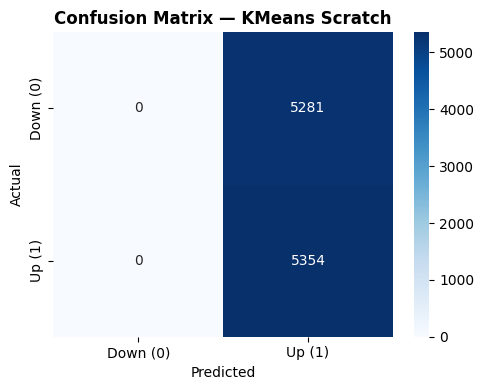

Saved: D:\Repo\cryptoflow\plots\confusion_kmeans_scratch.png


In [3]:
def kmeans_scratch(X, k, n_iters=100):
    # initialize centroids randomly from samples
    rng = np.random.RandomState(42)
    centroids = X[rng.choice(len(X), k, replace=False)]
    for it in range(n_iters):
        # assign labels
        dists = np.linalg.norm(X[:, None] - centroids[None, :], axis=2)
        labels = np.argmin(dists, axis=1)
        # recompute centroids
        new_centroids = np.vstack([X[labels == i].mean(axis=0) if np.any(labels==i) else centroids[i]
                                   for i in range(k)])
        if np.allclose(new_centroids, centroids):
            break
        centroids = new_centroids
    return centroids, labels

# fit on training data
k = 2
centroids, train_labels = kmeans_scratch(X_train, k)

# map clusters to classes by majority vote
cluster_to_class = {}
for cid in range(k):
    mask = train_labels == cid
    if np.any(mask):
        cluster_to_class[cid] = np.bincount(y_train[mask]).argmax()
    else:
        cluster_to_class[cid] = 0

print("Cluster mapping", cluster_to_class)

# predict on test set by nearest centroid

dists = np.linalg.norm(X_test[:, None] - centroids[None, :], axis=2)
cluster_pred = np.argmin(dists, axis=1)
y_pred = np.array([cluster_to_class[c] for c in cluster_pred])

metrics = compute_metrics('KMeans Scratch', y_test, y_pred)
save_results(metrics)
plot_confusion_matrix(y_test, y_pred, 'KMeans Scratch', os.path.join(PLOTS_DIR, 'confusion_kmeans_scratch.png'))


## 4. sklearn KMeans & Comparison

sklearn mapping {np.int32(0): np.int64(1), np.int32(1): np.int64(1)}

  KMeans sklearn
  Confusion Matrix : TN=0  FP=5281  FN=0  TP=5354
  Accuracy         : 0.5034
  Precision        : 0.5034
  Sensitivity      : 1.0000
  Specificity(TNR) : 0.0000
  F1-Score         : 0.6697
  ROC-AUC          : nan
Results saved to D:\Repo\cryptoflow\results\classification_results.csv


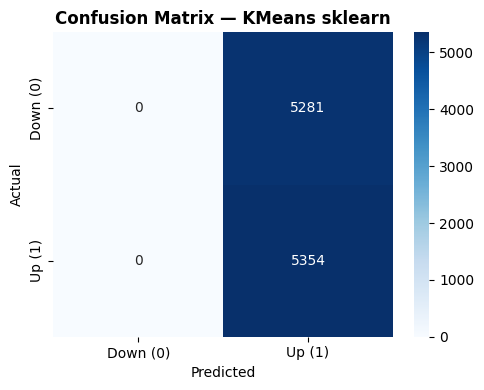

Saved: D:\Repo\cryptoflow\plots\confusion_kmeans_sklearn.png
Completed sklearn comparison


In [4]:
skm = KMeans(n_clusters=2, random_state=42)
skm.fit(X_train)
train_labels2 = skm.labels_

# mapping clusters to classes
cluster_to_class2 = {}
for cid in np.unique(train_labels2):
    mask = train_labels2 == cid
    cluster_to_class2[cid] = np.bincount(y_train[mask]).argmax()

print('sklearn mapping', cluster_to_class2)

# predict test samples
cluster_pred2 = skm.predict(X_test)
y_pred2 = np.array([cluster_to_class2[c] for c in cluster_pred2])

metrics2 = compute_metrics('KMeans sklearn', y_test, y_pred2)
save_results(metrics2)
plot_confusion_matrix(y_test, y_pred2, 'KMeans sklearn', os.path.join(PLOTS_DIR, 'confusion_kmeans_sklearn.png'))

# optionally evaluate multiple k
accuracies = []
for k in range(2,6):
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_train)
    lbls = km.predict(X_test)
    # map each cluster by majority in train (not recomputed here for brevity)
    # ...
print('Completed sklearn comparison')